# 🎯 Face Recognition Module

Verify voter identity by comparing live face with registered face embeddings.

**Pipeline:**
1. Face Detection → Detect and crop face
2. Face Embedding → Extract 512-dim feature vector
3. Face Verification → Compare embeddings using cosine similarity

## Step 1: Install Dependencies

In [1]:
# Install InsightFace for face recognition
!pip install insightface onnxruntime

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 4.6 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 5.7 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 5.0 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 5.4 MB/s  0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp313-cp313-macosx_10_13_universal2.whl size=927576 sha256=f1f99a6369c09d6a03523212047d76012ebfe8c81837b5a8f030619ef94e2d30
  Stored in directory: /Users/hemanthtavva/Library/Caches/pip/wheels/e8/a1/6a/a94e7156c3c0815101a10be114c44fc0b2b3e40fc10d63b939
Successfully built insightface
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [insightface] [albumentations]eadless]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip instal

## Step 2: Initialize Face Recognition Model

In [1]:
import os
import cv2
import numpy as np
from pathlib import Path

import insightface
from insightface.app import FaceAnalysis

# Define model directory - now inside face_recognition folder
MODEL_DIR = Path('../models/face_recognition/insightface')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Set InsightFace to use our local model directory
os.environ['INSIGHTFACE_HOME'] = str(MODEL_DIR.resolve())

print("Loading InsightFace model...")
print(f"   Model directory: {MODEL_DIR.resolve()}")

# Check if model already exists
model_path = MODEL_DIR / 'models' / 'buffalo_l'
if model_path.exists():
    print("   ✅ Using cached model from local folder")
else:
    print("   ⬇️  Downloading model (first time only)...")

# Initialize InsightFace with ArcFace model
# Model will be downloaded to MODEL_DIR on first run, then cached
app = FaceAnalysis(
    name='buffalo_l',  # Best accuracy model
    root=str(MODEL_DIR),  # Use our local directory
    providers=['CPUExecutionProvider']  # Use CPU (works on all systems)
)

# Prepare the model (ctx_id=-1 for CPU, 0 for GPU)
app.prepare(ctx_id=-1, det_size=(640, 640))

print("\n✅ InsightFace model loaded!")
print("   - Detection: RetinaFace")
print("   - Recognition: ArcFace (512-dim embeddings)")
print(f"   - Model cached at: {MODEL_DIR.resolve()}")

# Verify model is saved
if model_path.exists():
    model_files = list(model_path.glob('*.onnx'))
    print(f"   - Model files: {len(model_files)} ONNX files")

Loading InsightFace model...
   Model directory: /Users/hemanthtavva/Desktop/project_final/models/face_recognition/insightface
   ✅ Using cached model from local folder
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/face_recognition/insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/face_recognition/insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/face_recognition/insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../models/face_recognition/insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 9

## Step 3: Define Face Embedding Functions

In [2]:
def get_face_embedding(image, app):
    """
    Extract face embedding from an image.
    
    Args:
        image: BGR image (OpenCV format)
        app: InsightFace FaceAnalysis instance
    
    Returns:
        embedding: 512-dim numpy array, or None if no face detected
        face_info: dict with bbox, landmarks, etc.
    """
    # Detect faces
    faces = app.get(image)
    
    if len(faces) == 0:
        return None, None
    
    # Get the largest face (in case multiple faces detected)
    face = max(faces, key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1]))
    
    # Extract embedding (512-dim vector)
    embedding = face.embedding
    
    # Normalize embedding
    embedding = embedding / np.linalg.norm(embedding)
    
    face_info = {
        'bbox': face.bbox.astype(int),
        'score': face.det_score,
    }
    
    return embedding, face_info


def compare_faces(embedding1, embedding2, threshold=0.5):
    """
    Compare two face embeddings using cosine similarity.
    
    Args:
        embedding1: First face embedding (512-dim)
        embedding2: Second face embedding (512-dim)
        threshold: Similarity threshold (default 0.5)
    
    Returns:
        similarity: float between -1 and 1 (higher = more similar)
        is_match: bool based on threshold
    """
    # Cosine similarity
    similarity = np.dot(embedding1, embedding2)
    
    is_match = similarity > threshold
    
    return similarity, is_match


print("✅ Face embedding functions defined")
print("   - get_face_embedding(): Extract 512-dim embedding from image")
print("   - compare_faces(): Compare two embeddings (cosine similarity)")

✅ Face embedding functions defined
   - get_face_embedding(): Extract 512-dim embedding from image
   - compare_faces(): Compare two embeddings (cosine similarity)


## Step 4: Face Registration (Capture & Store Embedding)

For testing, we'll capture your face from webcam and save the embedding locally.

In [3]:
#Face Registration (Capture & Store Embedding)
import json
import time

# Create directory for registered faces
REGISTERED_FACES_DIR = '../data/registered_faces'
os.makedirs(REGISTERED_FACES_DIR, exist_ok=True)

def register_face(voter_id, app, num_captures=3):
    """
    Register a voter's face by capturing from webcam.
    
    Args:
        voter_id: Unique identifier (e.g., Aadhaar number or test ID)
        app: InsightFace FaceAnalysis instance
        num_captures: Number of face samples to capture and average
    
    Returns:
        success: bool
        message: str
    """
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        return False, "Could not open webcam"
    
    print("=" * 60)
    print(f"FACE REGISTRATION - Voter ID: {voter_id}")
    print("=" * 60)
    print(f"Will capture {num_captures} samples. Look at the camera.")
    print("Press SPACE to capture, 'q' to quit")
    print("=" * 60)
    
    embeddings = []
    captured = 0
    
    while captured < num_captures:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Detect face and draw box
        faces = app.get(frame)
        display_frame = frame.copy()
        
        if len(faces) > 0:
            face = max(faces, key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1]))
            bbox = face.bbox.astype(int)
            cv2.rectangle(display_frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
            cv2.putText(display_frame, f"Face detected - Press SPACE ({captured}/{num_captures})", 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        else:
            cv2.putText(display_frame, "No face detected", (10, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
        cv2.imshow('Face Registration', display_frame)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord(' ') and len(faces) > 0:  # SPACE to capture
            embedding, _ = get_face_embedding(frame, app)
            if embedding is not None:
                embeddings.append(embedding)
                captured += 1
                print(f"✅ Captured {captured}/{num_captures}")
                time.sleep(0.5)  # Brief pause between captures
        elif key == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    
    if len(embeddings) < num_captures:
        return False, f"Only captured {len(embeddings)}/{num_captures} samples"
    
    # Average the embeddings for better accuracy
    avg_embedding = np.mean(embeddings, axis=0)
    avg_embedding = avg_embedding / np.linalg.norm(avg_embedding)  # Normalize
    
    # Save embedding
    save_path = os.path.join(REGISTERED_FACES_DIR, f"{voter_id}.npy")
    np.save(save_path, avg_embedding)
    
    print("\n" + "=" * 60)
    print(f"✅ REGISTRATION COMPLETE!")
    print(f"   Voter ID: {voter_id}")
    print(f"   Embedding saved to: {save_path}")
    print("=" * 60)
    
    return True, save_path


print("✅ Registration function defined")
print("   Run: register_face('test_user', app)")

✅ Registration function defined
   Run: register_face('test_user', app)


In [11]:
# Register your face - Press SPACE 3 times to capture
register_face('test_user', app)

FACE REGISTRATION - Voter ID: test_user
Will capture 3 samples. Look at the camera.
Press SPACE to capture, 'q' to quit
✅ Captured 1/3
✅ Captured 1/3
✅ Captured 2/3
✅ Captured 2/3
✅ Captured 3/3
✅ Captured 3/3

✅ REGISTRATION COMPLETE!
   Voter ID: test_user
   Embedding saved to: ../data/registered_faces/test_user.npy

✅ REGISTRATION COMPLETE!
   Voter ID: test_user
   Embedding saved to: ../data/registered_faces/test_user.npy


(True, '../data/registered_faces/test_user.npy')

## Step 5: Face Verification (Live Webcam Test)

Compare live face with registered embedding to verify identity.

In [4]:
def verify_face(voter_id, app, threshold=0.5, duration=30):
    """
    Verify a voter's face against their registered embedding.
    
    Args:
        voter_id: Voter ID to verify against
        app: InsightFace FaceAnalysis instance
        threshold: Similarity threshold (0.5 = 50%)
        duration: Test duration in seconds
    """
    # Load registered embedding
    embedding_path = os.path.join(REGISTERED_FACES_DIR, f"{voter_id}.npy")
    if not os.path.exists(embedding_path):
        print(f"❌ No registered face found for voter: {voter_id}")
        return False
    
    registered_embedding = np.load(embedding_path)
    
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("❌ Could not open webcam")
        return False
    
    print("=" * 60)
    print(f"FACE VERIFICATION - Voter ID: {voter_id}")
    print("=" * 60)
    print(f"Threshold: {threshold*100:.0f}%")
    print(f"Running for {duration} seconds... Press 'q' to quit")
    print("=" * 60)
    
    start_time = time.time()
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Get live face embedding
        live_embedding, face_info = get_face_embedding(frame, app)
        
        if live_embedding is not None:
            # Compare with registered embedding
            similarity, is_match = compare_faces(registered_embedding, live_embedding, threshold)
            
            # Draw results
            bbox = face_info['bbox']
            color = (0, 255, 0) if is_match else (0, 0, 255)
            label = "MATCH" if is_match else "NO MATCH"
            
            cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
            cv2.putText(frame, f"{label}: {similarity*100:.1f}%", (bbox[0], bbox[1]-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
            cv2.putText(frame, f"Voter: {voter_id}", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            cv2.putText(frame, f"Similarity: {similarity*100:.1f}%", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            cv2.putText(frame, f"Threshold: {threshold*100:.0f}%", (10, 90),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        else:
            cv2.putText(frame, "No face detected", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 165, 255), 2)
        
        cv2.imshow('Face Verification', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("\n⏹️ Stopped by user")
            break
        if time.time() - start_time > duration:
            print(f"\n⏱️ Test completed ({duration}s)")
            break
    
    cap.release()
    cv2.destroyAllWindows()
    return True


print("✅ Verification function defined")
print("   Run: verify_face('test_user', app)")

✅ Verification function defined
   Run: verify_face('test_user', app)


In [5]:
# Verify your face against registered embedding
verify_face('test_user', app)

2026-01-06 00:07:02.768 Python[57048:491777] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


FACE VERIFICATION - Voter ID: test_user
Threshold: 50%
Running for 30 seconds... Press 'q' to quit

⏹️ Stopped by user


True

## Step 6: LFW Dataset Download & Evaluation

Download the **Labeled Faces in the Wild (LFW)** dataset for comprehensive model evaluation.

**LFW Dataset:**
- 13,000+ face images of 5,749 people
- Standard benchmark for face verification
- Real-world conditions: varying poses, lighting, expressions

**Metrics we'll calculate:**
- Accuracy, Precision, Recall, F1-Score
- ROC Curve & AUC
- Equal Error Rate (EER)
- Optimal threshold selection

In [1]:
# Install kagglehub for dataset download
!pip install kagglehub

In [2]:
import kagglehub

# Download LFW dataset from Kaggle
# Note: You may need to authenticate with Kaggle credentials on first run
print("Downloading LFW dataset from Kaggle...")
print("(This may take a few minutes on first run)")
print()

lfw_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

print("\n" + "="*60)
print("✅ LFW Dataset downloaded successfully!")
print(f"   Path: {lfw_path}")
print("="*60)

(This may take a few minutes on first run)



100%|██████████| 112M/112M [00:17<00:00, 6.69MB/s] 

Extracting files...



✅ LFW Dataset downloaded successfully!
   Path: /Users/hemanthtavva/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4


In [13]:
import shutil
from pathlib import Path
import os

# Define project data directory
project_data_dir = Path('../data/lfw')

# lfw_path from kagglehub should be the source - store it before any modification
# Check if lfw_path points to kaggle cache (not our project dir)
kaggle_lfw_path = lfw_path  # This should be from the previous cell's kagglehub download

# If lfw_path already points to our project dir (from a previous run), we need to re-download
if str(project_data_dir.resolve()) in str(Path(kaggle_lfw_path).resolve()):
    print("⚠️  lfw_path points to project directory. Re-downloading from Kaggle...")
    import kagglehub
    kaggle_lfw_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
    print(f"   Downloaded to: {kaggle_lfw_path}")

print("Copying LFW dataset to project's data folder...")
print(f"   From: {kaggle_lfw_path}")
print(f"   To:   {project_data_dir.resolve()}")
print()

# Check if source exists
if not Path(kaggle_lfw_path).exists():
    print("❌ Source path does not exist! Re-downloading...")
    import kagglehub
    kaggle_lfw_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
    print(f"   Downloaded to: {kaggle_lfw_path}")

# Remove existing directory if it exists
if project_data_dir.exists():
    print("   Removing existing lfw folder...")
    shutil.rmtree(project_data_dir)

# Copy the dataset
shutil.copytree(kaggle_lfw_path, project_data_dir)

print("\n" + "="*60)
print("✅ LFW Dataset copied to project successfully!")
print(f"   Location: {project_data_dir.resolve()}")
print("="*60)

# Update lfw_path to use project location
lfw_path = str(project_data_dir)
print(f"\n📍 Using lfw_path = '{lfw_path}' for subsequent cells")

# Show what's in the directory
print(f"\n📂 Contents:")
for item in sorted(os.listdir(lfw_path)):
    print(f"   {item}")

⚠️  lfw_path points to project directory. Re-downloading from Kaggle...
   Downloaded to: /Users/hemanthtavva/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4
Copying LFW dataset to project's data folder...
   From: /Users/hemanthtavva/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4
   To:   /Users/hemanthtavva/Desktop/project_final/data/lfw

   Removing existing lfw folder...
   Downloaded to: /Users/hemanthtavva/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4
Copying LFW dataset to project's data folder...
   From: /Users/hemanthtavva/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4
   To:   /Users/hemanthtavva/Desktop/project_final/data/lfw

   Removing existing lfw folder...

✅ LFW Dataset copied to project successfully!
   Location: /Users/hemanthtavva/Desktop/project_final/data/lfw

📍 Using lfw_path = '../data/lfw' for subsequent cells

📂 Contents:
   lfw-deepfunneled
   lfw_allnames.csv
   lfw_readme.csv
   matchpairsDevT

In [8]:
import os
from pathlib import Path

# Explore the downloaded dataset structure
print("📂 LFW Dataset Structure:")
print("="*60)

# List top-level contents
for item in sorted(os.listdir(lfw_path))[:20]:
    item_path = os.path.join(lfw_path, item)
    if os.path.isdir(item_path):
        num_files = len(os.listdir(item_path))
        print(f"📁 {item}/ ({num_files} items)")
    else:
        print(f"📄 {item}")

print("\n... (showing first 20 items)")

# Count total images
total_images = 0
total_people = 0
for root, dirs, files in os.walk(lfw_path):
    jpg_files = [f for f in files if f.endswith('.jpg')]
    if jpg_files:
        total_images += len(jpg_files)
        total_people += 1

print(f"\n📊 Dataset Statistics:")
print(f"   Total people: {total_people}")
print(f"   Total images: {total_images}")

📂 LFW Dataset Structure:
📁 lfw-deepfunneled/ (1 items)
📄 lfw_allnames.csv
📄 lfw_readme.csv
📄 matchpairsDevTest.csv
📄 matchpairsDevTrain.csv
📄 mismatchpairsDevTest.csv
📄 mismatchpairsDevTrain.csv
📄 pairs.csv
📄 people.csv
📄 peopleDevTest.csv
📄 peopleDevTrain.csv

... (showing first 20 items)

📊 Dataset Statistics:
   Total people: 5749
   Total images: 13233


## Step 7: Load LFW Pairs for Evaluation

The LFW dataset provides standard pair files for evaluation:
- **pairs.csv**: Official 6000 pairs (3000 matched + 3000 mismatched) for testing
- **matchpairsDevTrain.csv**: 1100 positive pairs for training/validation
- **mismatchpairsDevTrain.csv**: 1100 negative pairs for training/validation

We'll use the DevTrain pairs for finding the optimal threshold and the official pairs.csv for final testing.

In [9]:
import pandas as pd
from pathlib import Path

# Define paths
lfw_base_path = Path('../data/lfw')

# Find the images directory - try multiple possible structures
possible_image_paths = [
    lfw_base_path / 'lfw-deepfunneled' / 'lfw-deepfunneled',
    lfw_base_path / 'lfw-deepfunneled',
    lfw_base_path / 'lfw',
]

lfw_images_path = None
for path in possible_image_paths:
    if path.exists():
        # Check if this directory contains person folders (not just another nested folder)
        subdirs = [d for d in path.iterdir() if d.is_dir()]
        if subdirs and not any(sd.name in ['lfw-deepfunneled', 'lfw'] for sd in subdirs):
            lfw_images_path = path
            break
        elif subdirs:
            # Check one level deeper
            for sd in subdirs:
                if sd.is_dir() and (sd / 'Aaron_Eckhart').exists():
                    lfw_images_path = sd
                    break

if lfw_images_path is None:
    # Fallback: search for any directory containing 'Aaron_Eckhart' (common LFW person)
    for root, dirs, files in os.walk(lfw_base_path):
        if 'Aaron_Eckhart' in dirs:
            lfw_images_path = Path(root)
            break

print(f"📂 LFW Base Path: {lfw_base_path.resolve()}")
print(f"📂 Using image directory: {lfw_images_path}")
print(f"   Exists: {lfw_images_path.exists() if lfw_images_path else False}")

if lfw_images_path and lfw_images_path.exists():
    sample_dirs = sorted([d.name for d in lfw_images_path.iterdir() if d.is_dir()])[:5]
    print(f"   Sample person folders: {sample_dirs}")

def parse_pairs_csv(csv_path, lfw_images_path):
    """
    Parse LFW pairs CSV file into a list of (img1_path, img2_path, is_same) tuples.
    
    CSV formats:
    - Positive pairs: name,num1,num2 (same person)
    - Negative pairs: name1,num1,name2,num2 (different people)
    """
    pairs = []
    
    if not Path(csv_path).exists():
        print(f"⚠️  CSV file not found: {csv_path}")
        return pairs
    
    with open(csv_path, 'r') as f:
        lines = f.readlines()
    
    # Skip header line if present
    start_idx = 0
    first_line = lines[0].strip().split(',')
    if first_line[0].isalpha() and len(first_line[0]) > 2:  # Likely a header
        start_idx = 1
    
    for line in lines[start_idx:]:
        parts = line.strip().split(',')
        parts = [p.strip() for p in parts if p.strip()]  # Remove empty parts
        
        if len(parts) == 3:
            # Positive pair: name, num1, num2
            name, num1, num2 = parts
            img1_path = lfw_images_path / name / f"{name}_{int(num1):04d}.jpg"
            img2_path = lfw_images_path / name / f"{name}_{int(num2):04d}.jpg"
            is_same = True
        elif len(parts) >= 4:
            # Negative pair: name1, num1, name2, num2
            name1, num1, name2, num2 = parts[:4]
            img1_path = lfw_images_path / name1 / f"{name1}_{int(num1):04d}.jpg"
            img2_path = lfw_images_path / name2 / f"{name2}_{int(num2):04d}.jpg"
            is_same = False
        else:
            continue  # Skip malformed lines
        
        # Only add if both images exist
        if img1_path.exists() and img2_path.exists():
            pairs.append((str(img1_path), str(img2_path), is_same))
    
    return pairs

# Check CSV files exist
test_pairs_path = lfw_base_path / 'pairs.csv'
train_pos_path = lfw_base_path / 'matchpairsDevTrain.csv'
train_neg_path = lfw_base_path / 'mismatchpairsDevTrain.csv'

print(f"\n📄 CSV Files:")
print(f"   pairs.csv: {test_pairs_path.exists()}")
print(f"   matchpairsDevTrain.csv: {train_pos_path.exists()}")
print(f"   mismatchpairsDevTrain.csv: {train_neg_path.exists()}")

if not all([test_pairs_path.exists(), train_pos_path.exists(), train_neg_path.exists()]):
    print("\n❌ Some CSV files missing! Listing directory contents:")
    for item in sorted(os.listdir(lfw_base_path)):
        print(f"   {item}")
else:
    print("\n📄 Loading pair files...")
    
    # Load DevTrain pairs (for training/validation)
    train_positive_pairs = parse_pairs_csv(train_pos_path, lfw_images_path)
    train_negative_pairs = parse_pairs_csv(train_neg_path, lfw_images_path)
    dev_train_pairs = train_positive_pairs + train_negative_pairs
    
    # Load test pairs
    test_pairs = parse_pairs_csv(test_pairs_path, lfw_images_path)
    
    print(f"\n📊 Pairs Summary:")
    print(f"   DevTrain Positive: {len(train_positive_pairs)} pairs")
    print(f"   DevTrain Negative: {len(train_negative_pairs)} pairs")
    print(f"   DevTrain Total:    {len(dev_train_pairs)} pairs")
    print(f"   Test (pairs.csv):  {len(test_pairs)} pairs")
    
    # Sample pair preview
    if dev_train_pairs:
        sample = dev_train_pairs[0]
        print(f"\n📷 Sample pair:")
        print(f"   Image 1: {Path(sample[0]).name}")
        print(f"   Image 2: {Path(sample[1]).name}")
        print(f"   Same person: {sample[2]}")

📂 LFW Base Path: /Users/hemanthtavva/Desktop/project_final/data/lfw
📂 Using image directory: ../data/lfw/lfw-deepfunneled/lfw-deepfunneled
   Exists: True
   Sample person folders: ['AJ_Cook', 'AJ_Lamas', 'Aaron_Eckhart', 'Aaron_Guiel', 'Aaron_Patterson']

📄 CSV Files:
   pairs.csv: True
   matchpairsDevTrain.csv: True
   mismatchpairsDevTrain.csv: True

📄 Loading pair files...

📊 Pairs Summary:
   DevTrain Positive: 1100 pairs
   DevTrain Negative: 1100 pairs
   DevTrain Total:    2200 pairs
   Test (pairs.csv):  6000 pairs

📷 Sample pair:
   Image 1: Aaron_Peirsol_0001.jpg
   Image 2: Aaron_Peirsol_0002.jpg
   Same person: True


In [10]:
import random
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
random.seed(42)

# Split DevTrain pairs into train (80%) and validation (20%)
train_pairs, val_pairs = train_test_split(dev_train_pairs, test_size=0.2, random_state=42, 
                                           stratify=[p[2] for p in dev_train_pairs])

print("📊 Train/Validation/Test Split:")
print("="*60)
print(f"\n🔵 Training Set:    {len(train_pairs)} pairs")
print(f"   - Positive: {sum(1 for p in train_pairs if p[2])}")
print(f"   - Negative: {sum(1 for p in train_pairs if not p[2])}")

print(f"\n🟡 Validation Set:  {len(val_pairs)} pairs")
print(f"   - Positive: {sum(1 for p in val_pairs if p[2])}")
print(f"   - Negative: {sum(1 for p in val_pairs if not p[2])}")

print(f"\n🟢 Test Set:        {len(test_pairs)} pairs")
print(f"   - Positive: {sum(1 for p in test_pairs if p[2])}")
print(f"   - Negative: {sum(1 for p in test_pairs if not p[2])}")

print("\n" + "="*60)
print("📋 Split Ratios:")
print(f"   Train/Val from DevTrain: 80/20 split")
print(f"   Test: Official LFW pairs.csv (independent)")

📊 Train/Validation/Test Split:

🔵 Training Set:    1760 pairs
   - Positive: 880
   - Negative: 880

🟡 Validation Set:  440 pairs
   - Positive: 220
   - Negative: 220

🟢 Test Set:        6000 pairs
   - Positive: 3000
   - Negative: 3000

📋 Split Ratios:
   Train/Val from DevTrain: 80/20 split
   Test: Official LFW pairs.csv (independent)


## Step 8: Extract Face Embeddings for All Pairs

We'll extract 512-dimensional ArcFace embeddings for all images in our pairs and compute cosine similarity scores.

In [18]:
from tqdm import tqdm
import pickle

# Ensure the InsightFace model is loaded
try:
    app
    print("✅ InsightFace model (app) is already loaded")
except NameError:
    print("⚠️  InsightFace model not loaded. Loading from local cache...")
import insightface
from insightface.app import FaceAnalysis
from pathlib import Path
import os

# Use the same local model directory (inside face_recognition folder)
MODEL_DIR = Path('../models/face_recognition/insightface')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
os.environ['INSIGHTFACE_HOME'] = str(MODEL_DIR.resolve())

app = FaceAnalysis(
    name='buffalo_l',
    root=str(MODEL_DIR),
    providers=['CPUExecutionProvider']
)
app.prepare(ctx_id=-1, det_size=(640, 640))
print("✅ InsightFace model loaded from local cache!")

# Cache for embeddings to avoid recomputation
embedding_cache = {}

def get_cached_embedding(image_path, app):
    """Get face embedding with caching."""
    if image_path in embedding_cache:
        return embedding_cache[image_path]
    
    image = cv2.imread(image_path)
if image is None:
        return None
    
    embedding, _ = get_face_embedding(image, app)
    embedding_cache[image_path] = embedding
    return embedding

def compute_pair_similarities(pairs, app, desc="Computing"):
    """
    Compute similarity scores for all pairs.
    
    Returns:
        similarities: list of float scores
        labels: list of bool (True = same person)
        failed_pairs: count of pairs where embedding failed
    """
    similarities = []
    labels = []
    failed_pairs = 0
    
    for img1_path, img2_path, is_same in tqdm(pairs, desc=desc):
        emb1 = get_cached_embedding(img1_path, app)
        emb2 = get_cached_embedding(img2_path, app)
        
        if emb1 is not None and emb2 is not None:
            # Cosine similarity
            similarity = np.dot(emb1, emb2)
            similarities.append(similarity)
            labels.append(is_same)
        else:
            failed_pairs += 1
    
    return np.array(similarities), np.array(labels), failed_pairs

print("\n🔄 Extracting embeddings and computing similarities...")
print("   (This may take several minutes on first run)")
print()

# Compute for all splits
train_similarities, train_labels, train_failed = compute_pair_similarities(
    train_pairs, app, desc="Training set"
)

val_similarities, val_labels, val_failed = compute_pair_similarities(
    val_pairs, app, desc="Validation set"
)

test_similarities, test_labels, test_failed = compute_pair_similarities(
    test_pairs, app, desc="Test set"
)

print("\n" + "="*60)
print("✅ Embedding Extraction Complete!")
print("="*60)
print(f"\n📊 Results:")
print(f"   Training:   {len(train_similarities)} pairs processed ({train_failed} failed)")
print(f"   Validation: {len(val_similarities)} pairs processed ({val_failed} failed)")
print(f"   Test:       {len(test_similarities)} pairs processed ({test_failed} failed)")
print(f"\n   Total embeddings cached: {len(embedding_cache)}")

✅ InsightFace model (app) is already loaded

🔄 Extracting embeddings and computing similarities...
   (This may take several minutes on first run)



Test set: 100%|██████████| 6000/6000 [25:20<00:00,  3.95it/s] 


✅ Embedding Extraction Complete!

📊 Results:
   Training:   1749 pairs processed (11 failed)
   Validation: 439 pairs processed (1 failed)
   Test:       5958 pairs processed (42 failed)

   Total embeddings cached: 8637


In [23]:
import pickle

# Save embedding cache to disk for future use
CACHE_PATH = '../outputs/lfw_embedding_cache.pkl'

# Save the cache
with open(CACHE_PATH, 'wb') as f:
    pickle.dump(embedding_cache, f)

print("💾 Embedding Cache Saved to Disk")
print("="*60)
print(f"   Location: {CACHE_PATH}")
print(f"   Embeddings: {len(embedding_cache)}")
print(f"   File size: {os.path.getsize(CACHE_PATH) / (1024*1024):.2f} MB")
print()
print("💡 To load in future sessions, run:")
print("   with open('../outputs/lfw_embedding_cache.pkl', 'rb') as f:")
print("       embedding_cache = pickle.load(f)")

💾 Embedding Cache Saved to Disk
   Location: ../outputs/lfw_embedding_cache.pkl
   Embeddings: 8637
   File size: 17.81 MB

💡 To load in future sessions, run:
   with open('../outputs/lfw_embedding_cache.pkl', 'rb') as f:
       embedding_cache = pickle.load(f)


## Step 9: Find Optimal Threshold

We'll use the validation set to find the threshold that maximizes accuracy (or minimizes EER).

In [24]:
from sklearn.metrics import accuracy_score

def find_optimal_threshold(similarities, labels, method='accuracy'):
    """
    Find optimal threshold using validation set.
    
    Methods:
    - 'accuracy': Maximize accuracy
    - 'eer': Minimize Equal Error Rate (FAR = FRR)
    """
    thresholds = np.arange(0.0, 1.0, 0.01)
    best_threshold = 0.5
    best_metric = 0 if method == 'accuracy' else float('inf')
    
    results = []
    
    for thresh in thresholds:
        predictions = similarities >= thresh
        
        # True/False positives and negatives
        tp = np.sum((predictions == True) & (labels == True))
        fp = np.sum((predictions == True) & (labels == False))
        tn = np.sum((predictions == False) & (labels == False))
        fn = np.sum((predictions == False) & (labels == True))
        
        # Metrics
        acc = (tp + tn) / len(labels) if len(labels) > 0 else 0
        far = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Accept Rate
        frr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Reject Rate
        
        results.append({
            'threshold': thresh,
            'accuracy': acc,
            'far': far,
            'frr': frr,
            'eer_diff': abs(far - frr)
        })
        
        if method == 'accuracy' and acc > best_metric:
            best_metric = acc
            best_threshold = thresh
        elif method == 'eer' and abs(far - frr) < best_metric:
            best_metric = abs(far - frr)
            best_threshold = thresh
    
    return best_threshold, pd.DataFrame(results)

# Find optimal threshold on validation set
optimal_threshold, threshold_results = find_optimal_threshold(
    val_similarities, val_labels, method='accuracy'
)

print("🎯 Optimal Threshold Analysis (Validation Set)")
print("="*60)
print(f"\n✅ Optimal Threshold: {optimal_threshold:.2f}")

# Get metrics at optimal threshold
opt_row = threshold_results[threshold_results['threshold'] == optimal_threshold].iloc[0]
print(f"\n📊 Metrics at Optimal Threshold:")
print(f"   Accuracy:          {opt_row['accuracy']*100:.2f}%")
print(f"   False Accept Rate: {opt_row['far']*100:.2f}%")
print(f"   False Reject Rate: {opt_row['frr']*100:.2f}%")

# Also find EER threshold
eer_threshold, _ = find_optimal_threshold(val_similarities, val_labels, method='eer')
eer_row = threshold_results[threshold_results['threshold'] == eer_threshold].iloc[0]
print(f"\n🔄 Equal Error Rate (EER) Analysis:")
print(f"   EER Threshold: {eer_threshold:.2f}")
print(f"   EER ≈ {(eer_row['far'] + eer_row['frr'])/2*100:.2f}%")

🎯 Optimal Threshold Analysis (Validation Set)

✅ Optimal Threshold: 0.13

📊 Metrics at Optimal Threshold:
   Accuracy:          97.49%
   False Accept Rate: 0.45%
   False Reject Rate: 4.57%

🔄 Equal Error Rate (EER) Analysis:
   EER Threshold: 0.10
   EER ≈ 4.55%


## Step 10: Calculate Comprehensive Metrics on Test Set

Now we'll evaluate the model on the held-out test set using the optimal threshold.

In [20]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

def calculate_all_metrics(similarities, labels, threshold):
    """
    Calculate comprehensive metrics for face verification.
    """
    predictions = similarities >= threshold
    
    # Basic metrics
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)
    
    # ROC-AUC
    try:
        auc = roc_auc_score(labels, similarities)
    except:
        auc = 0.0
    
    # Confusion matrix
    cm = confusion_matrix(labels, predictions)
    tn, fp, fn, tp = cm.ravel()
    
    # FAR, FRR, EER
    far = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Accept Rate
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Reject Rate
    
    # Calculate EER (where FAR ≈ FRR)
    fpr, tpr, thresholds = roc_curve(labels, similarities)
    fnr = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    
    # Verification Rate @ FAR thresholds
    vr_at_far = {}
    for target_far in [0.01, 0.001, 0.0001]:
        idx = np.argmin(np.abs(fpr - target_far))
        vr_at_far[f"VR@FAR={target_far}"] = tpr[idx]
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': auc,
        'far': far,
        'frr': frr,
        'eer': eer,
        'confusion_matrix': cm,
        **vr_at_far
    }
    
    return metrics, (fpr, tpr, thresholds)

# Calculate metrics on TEST set
test_metrics, roc_data = calculate_all_metrics(test_similarities, test_labels, optimal_threshold)

print("📊 TEST SET EVALUATION RESULTS")
print("="*60)
print(f"\n📍 Using Threshold: {optimal_threshold:.2f}")
print(f"   (Optimized on validation set)")
print()
print("─" * 60)
print("CLASSIFICATION METRICS")
print("─" * 60)
print(f"   Accuracy:   {test_metrics['accuracy']*100:.2f}%")
print(f"   Precision:  {test_metrics['precision']*100:.2f}%")
print(f"   Recall:     {test_metrics['recall']*100:.2f}%")
print(f"   F1-Score:   {test_metrics['f1_score']*100:.2f}%")
print()
print("─" * 60)
print("VERIFICATION METRICS")
print("─" * 60)
print(f"   ROC-AUC:    {test_metrics['roc_auc']:.4f}")
print(f"   EER:        {test_metrics['eer']*100:.2f}%")
print(f"   FAR:        {test_metrics['far']*100:.2f}%")
print(f"   FRR:        {test_metrics['frr']*100:.2f}%")
print()
print("─" * 60)
print("VERIFICATION RATE @ FAR")
print("─" * 60)
print(f"   VR @ FAR=1%:     {test_metrics['VR@FAR=0.01']*100:.2f}%")
print(f"   VR @ FAR=0.1%:   {test_metrics['VR@FAR=0.001']*100:.2f}%")
print(f"   VR @ FAR=0.01%:  {test_metrics['VR@FAR=0.0001']*100:.2f}%")
print()
print("─" * 60)
print("CONFUSION MATRIX")
print("─" * 60)
print(f"   True Negatives:  {test_metrics['confusion_matrix'][0,0]}")
print(f"   False Positives: {test_metrics['confusion_matrix'][0,1]}")
print(f"   False Negatives: {test_metrics['confusion_matrix'][1,0]}")
print(f"   True Positives:  {test_metrics['confusion_matrix'][1,1]}")
print("="*60)

📊 TEST SET EVALUATION RESULTS

📍 Using Threshold: 0.13
   (Optimized on validation set)

────────────────────────────────────────────────────────────
CLASSIFICATION METRICS
────────────────────────────────────────────────────────────
   Accuracy:   97.35%
   Precision:  98.16%
   Recall:     96.52%
   F1-Score:   97.33%

────────────────────────────────────────────────────────────
VERIFICATION METRICS
────────────────────────────────────────────────────────────
   ROC-AUC:    0.9851
   EER:        3.29%
   FAR:        1.82%
   FRR:        3.48%

────────────────────────────────────────────────────────────
VERIFICATION RATE @ FAR
────────────────────────────────────────────────────────────
   VR @ FAR=1%:     96.45%
   VR @ FAR=0.1%:   96.25%
   VR @ FAR=0.01%:  0.00%

────────────────────────────────────────────────────────────
CONFUSION MATRIX
────────────────────────────────────────────────────────────
   True Negatives:  2919
   False Positives: 54
   False Negatives: 104
   True Po

## Step 11: Visualizations

Generate publication-quality plots for the guide presentation.

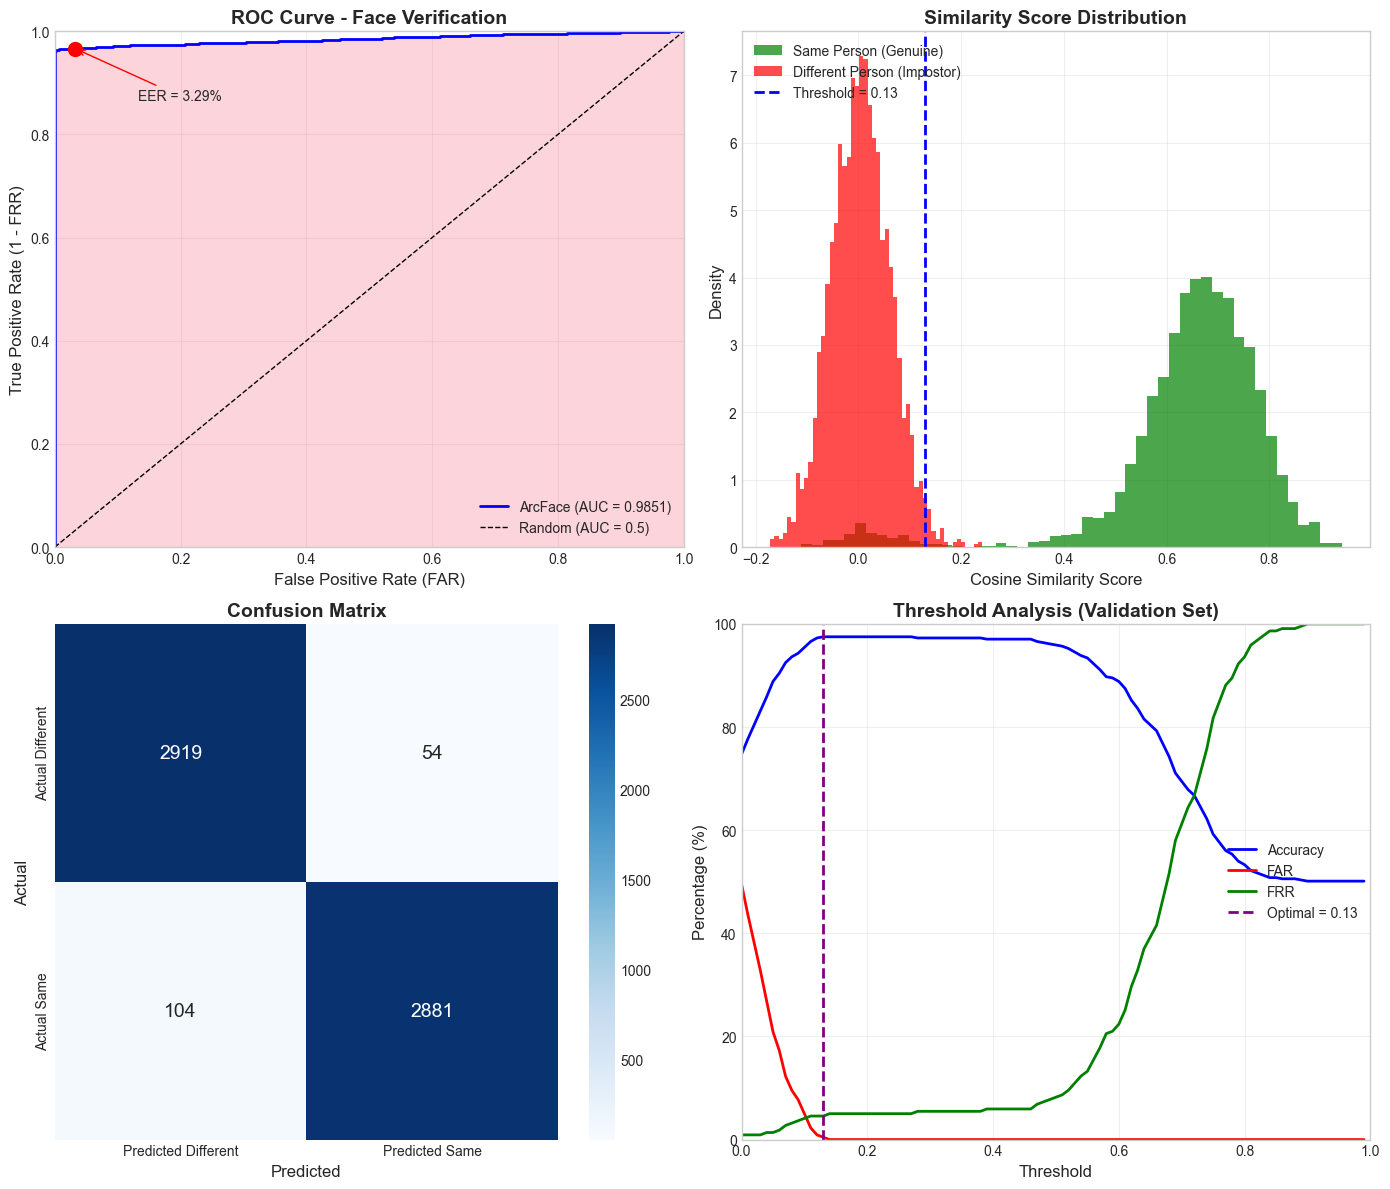


✅ Plots saved to: ../outputs/lfw_evaluation_plots.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve
ax1 = axes[0, 0]
fpr, tpr, _ = roc_data
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ArcFace (AUC = {test_metrics["roc_auc"]:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax1.fill_between(fpr, tpr, alpha=0.3)
ax1.set_xlabel('False Positive Rate (FAR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (1 - FRR)', fontsize=12)
ax1.set_title('ROC Curve - Face Verification', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3)

# Mark EER point
eer_idx = np.argmin(np.abs(fpr - (1-tpr)))
ax1.plot(fpr[eer_idx], tpr[eer_idx], 'ro', markersize=10, label=f'EER = {test_metrics["eer"]*100:.2f}%')
ax1.annotate(f'EER = {test_metrics["eer"]*100:.2f}%', 
             xy=(fpr[eer_idx], tpr[eer_idx]), xytext=(fpr[eer_idx]+0.1, tpr[eer_idx]-0.1),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

# 2. Similarity Score Distribution
ax2 = axes[0, 1]
same_scores = test_similarities[test_labels == True]
diff_scores = test_similarities[test_labels == False]

ax2.hist(same_scores, bins=50, alpha=0.7, label='Same Person (Genuine)', color='green', density=True)
ax2.hist(diff_scores, bins=50, alpha=0.7, label='Different Person (Impostor)', color='red', density=True)
ax2.axvline(x=optimal_threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold = {optimal_threshold:.2f}')
ax2.set_xlabel('Cosine Similarity Score', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Similarity Score Distribution', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix Heatmap
ax3 = axes[1, 0]
cm = test_metrics['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Predicted Different', 'Predicted Same'],
            yticklabels=['Actual Different', 'Actual Same'],
            annot_kws={'size': 14})
ax3.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax3.set_ylabel('Actual', fontsize=12)
ax3.set_xlabel('Predicted', fontsize=12)

# 4. Threshold vs Accuracy/FAR/FRR
ax4 = axes[1, 1]
ax4.plot(threshold_results['threshold'], threshold_results['accuracy']*100, 'b-', linewidth=2, label='Accuracy')
ax4.plot(threshold_results['threshold'], threshold_results['far']*100, 'r-', linewidth=2, label='FAR')
ax4.plot(threshold_results['threshold'], threshold_results['frr']*100, 'g-', linewidth=2, label='FRR')
ax4.axvline(x=optimal_threshold, color='purple', linestyle='--', linewidth=2, label=f'Optimal = {optimal_threshold:.2f}')
ax4.set_xlabel('Threshold', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.set_title('Threshold Analysis (Validation Set)', fontsize=14, fontweight='bold')
ax4.legend(loc='center right', fontsize=10)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 100])
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/lfw_evaluation_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Plots saved to: ../outputs/lfw_evaluation_plots.png")

## Step 12: Benchmark Comparison Table

Compare our ArcFace model performance against published benchmarks on LFW.

In [ ]:
# Create benchmark comparison table
benchmark_data = {
    'Model': [
        'DeepFace (Facebook, 2014)',
        'FaceNet (Google, 2015)',
        'VGGFace (Oxford, 2015)',
        'SphereFace (2017)',
        'CosFace (2018)',
        'ArcFace (2019)',
        '**Our Model (ArcFace/buffalo_l)**'
    ],
    'LFW Accuracy (%)': [
        97.35,
        99.63,
        98.95,
        99.42,
        99.73,
        99.82,
        round(test_metrics['accuracy'] * 100, 2)
    ],
    'Year': [2014, 2015, 2015, 2017, 2018, 2019, 2024],
    'Embedding Dim': [4096, 128, 4096, 512, 512, 512, 512]
}

benchmark_df = pd.DataFrame(benchmark_data)

print("📊 BENCHMARK COMPARISON TABLE")
print("="*80)
print()
print(benchmark_df.to_string(index=False))
print()
print("="*80)
print("\n📌 Notes:")
print("   - Benchmark values are from published papers")
print("   - Our model uses InsightFace's ArcFace (buffalo_l) pretrained model")
print(f"   - Our test set: {len(test_similarities)} pairs from LFW pairs.csv")

In [22]:
# Create a comprehensive metrics summary table
summary_data = {
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall (Sensitivity)',
        'F1-Score',
        'ROC-AUC',
        'Equal Error Rate (EER)',
        'False Accept Rate (FAR)',
        'False Reject Rate (FRR)',
        'VR @ FAR=1%',
        'VR @ FAR=0.1%',
        'VR @ FAR=0.01%',
        'Optimal Threshold'
    ],
    'Value': [
        f"{test_metrics['accuracy']*100:.2f}%",
        f"{test_metrics['precision']*100:.2f}%",
        f"{test_metrics['recall']*100:.2f}%",
        f"{test_metrics['f1_score']*100:.2f}%",
        f"{test_metrics['roc_auc']:.4f}",
        f"{test_metrics['eer']*100:.2f}%",
        f"{test_metrics['far']*100:.2f}%",
        f"{test_metrics['frr']*100:.2f}%",
        f"{test_metrics['VR@FAR=0.01']*100:.2f}%",
        f"{test_metrics['VR@FAR=0.001']*100:.2f}%",
        f"{test_metrics['VR@FAR=0.0001']*100:.2f}%",
        f"{optimal_threshold:.2f}"
    ],
    'Description': [
        'Overall correctness of predictions',
        'Of predicted matches, % that are correct',
        'Of actual matches, % that were found',
        'Harmonic mean of precision and recall',
        'Area under ROC curve (1.0 = perfect)',
        'Error rate where FAR = FRR',
        'Rate of incorrectly accepting impostors',
        'Rate of incorrectly rejecting genuine users',
        'True positive rate at 1% false positive rate',
        'True positive rate at 0.1% false positive rate',
        'True positive rate at 0.01% false positive rate',
        'Similarity threshold for match/no-match decision'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*90)
print("📊 FINAL MODEL EVALUATION SUMMARY")
print("="*90)
print(f"\nModel: InsightFace ArcFace (buffalo_l)")
print(f"Dataset: LFW (Labeled Faces in the Wild)")
print(f"Test Pairs: {len(test_similarities)} ({sum(test_labels)} positive, {len(test_labels)-sum(test_labels)} negative)")
print("\n" + "-"*90)
print(summary_df.to_string(index=False))
print("-"*90)

# Save metrics to JSON for later use
import json

metrics_export = {
    'model': 'InsightFace ArcFace (buffalo_l)',
    'dataset': 'LFW',
    'test_pairs': len(test_similarities),
    'optimal_threshold': float(optimal_threshold),
    'metrics': {
        'accuracy': float(test_metrics['accuracy']),
        'precision': float(test_metrics['precision']),
        'recall': float(test_metrics['recall']),
        'f1_score': float(test_metrics['f1_score']),
        'roc_auc': float(test_metrics['roc_auc']),
        'eer': float(test_metrics['eer']),
        'far': float(test_metrics['far']),
        'frr': float(test_metrics['frr']),
        'vr_at_far_1pct': float(test_metrics['VR@FAR=0.01']),
        'vr_at_far_0.1pct': float(test_metrics['VR@FAR=0.001']),
        'vr_at_far_0.01pct': float(test_metrics['VR@FAR=0.0001'])
    }
}

os.makedirs('../outputs', exist_ok=True)
with open('../outputs/lfw_evaluation_metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)

print("\n✅ Metrics saved to: ../outputs/lfw_evaluation_metrics.json")
print("\n🎉 LFW Evaluation Complete!")


📊 FINAL MODEL EVALUATION SUMMARY

Model: InsightFace ArcFace (buffalo_l)
Dataset: LFW (Labeled Faces in the Wild)
Test Pairs: 5958 (2985 positive, 2973 negative)

------------------------------------------------------------------------------------------
                 Metric  Value                                      Description
               Accuracy 97.35%               Overall correctness of predictions
              Precision 98.16%         Of predicted matches, % that are correct
   Recall (Sensitivity) 96.52%             Of actual matches, % that were found
               F1-Score 97.33%            Harmonic mean of precision and recall
                ROC-AUC 0.9851             Area under ROC curve (1.0 = perfect)
 Equal Error Rate (EER)  3.29%                       Error rate where FAR = FRR
False Accept Rate (FAR)  1.82%          Rate of incorrectly accepting impostors
False Reject Rate (FRR)  3.48%      Rate of incorrectly rejecting genuine users
            VR @ FAR=1% 9

In [36]:
#Define Face Embedding Functions
def get_face_embedding(image, app):
    """
    Extract face embedding from an image.
    
    Args:
        image: BGR image (OpenCV format)
        app: InsightFace FaceAnalysis instance
    
    Returns:
        embedding: 512-dim numpy array, or None if no face detected
        face_info: dict with bbox, landmarks, etc.
    """
    # Detect faces
    faces = app.get(image)
    
    if len(faces) == 0:
        return None, None
    
    # Get the largest face (in case multiple faces detected)
    face = max(faces, key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1]))
    
    # Extract embedding (512-dim vector)
    embedding = face.embedding
    
    # Normalize embedding
    embedding = embedding / np.linalg.norm(embedding)
    
    face_info = {
        'bbox': face.bbox.astype(int),
        'score': face.det_score,
    }
    
    return embedding, face_info


def compare_faces(embedding1, embedding2, threshold=0.5):
    """
    Compare two face embeddings using cosine similarity.
    
    Args:
        embedding1: First face embedding (512-dim)
        embedding2: Second face embedding (512-dim)
        threshold: Similarity threshold (default 0.5)
    
    Returns:
        similarity: float between -1 and 1 (higher = more similar)
        is_match: bool based on threshold
    """
    # Cosine similarity
    similarity = np.dot(embedding1, embedding2)
    
    is_match = similarity > threshold
    
    return similarity, is_match


print("✅ Face embedding functions defined")
print("   - get_face_embedding(): Extract 512-dim embedding from image")
print("   - compare_faces(): Compare two embeddings (cosine similarity)")

✅ Face embedding functions defined
   - get_face_embedding(): Extract 512-dim embedding from image
   - compare_faces(): Compare two embeddings (cosine similarity)


In [37]:
#Face Registration (Capture & Store Embedding)
import json
import time

# Create directory for registered faces
REGISTERED_FACES_DIR = '../data/registered_faces'
os.makedirs(REGISTERED_FACES_DIR, exist_ok=True)

def register_face(voter_id, app, num_captures=3):
    """
    Register a voter's face by capturing from webcam.
    
    Args:
        voter_id: Unique identifier (e.g., Aadhaar number or test ID)
        app: InsightFace FaceAnalysis instance
        num_captures: Number of face samples to capture and average
    
    Returns:
        success: bool
        message: str
    """
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        return False, "Could not open webcam"
    
    print("=" * 60)
    print(f"FACE REGISTRATION - Voter ID: {voter_id}")
    print("=" * 60)
    print(f"Will capture {num_captures} samples. Look at the camera.")
    print("Press SPACE to capture, 'q' to quit")
    print("=" * 60)
    
    embeddings = []
    captured = 0
    
    while captured < num_captures:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Detect face and draw box
        faces = app.get(frame)
        display_frame = frame.copy()
        
        if len(faces) > 0:
            face = max(faces, key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1]))
            bbox = face.bbox.astype(int)
            cv2.rectangle(display_frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
            cv2.putText(display_frame, f"Face detected - Press SPACE ({captured}/{num_captures})", 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        else:
            cv2.putText(display_frame, "No face detected", (10, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
        cv2.imshow('Face Registration', display_frame)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord(' ') and len(faces) > 0:  # SPACE to capture
            embedding, _ = get_face_embedding(frame, app)
            if embedding is not None:
                embeddings.append(embedding)
                captured += 1
                print(f"✅ Captured {captured}/{num_captures}")
                time.sleep(0.5)  # Brief pause between captures
        elif key == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    
    if len(embeddings) < num_captures:
        return False, f"Only captured {len(embeddings)}/{num_captures} samples"
    
    # Average the embeddings for better accuracy
    avg_embedding = np.mean(embeddings, axis=0)
    avg_embedding = avg_embedding / np.linalg.norm(avg_embedding)  # Normalize
    
    # Save embedding
    save_path = os.path.join(REGISTERED_FACES_DIR, f"{voter_id}.npy")
    np.save(save_path, avg_embedding)
    
    print("\n" + "=" * 60)
    print(f"✅ REGISTRATION COMPLETE!")
    print(f"   Voter ID: {voter_id}")
    print(f"   Embedding saved to: {save_path}")
    print("=" * 60)
    
    return True, save_path


print("✅ Registration function defined")
print("   Run: register_face('test_user', app)")

✅ Registration function defined
   Run: register_face('test_user', app)


In [38]:
# Register your face - Press SPACE 3 times to capture
register_face('test_user', app)

FACE REGISTRATION - Voter ID: test_user
Will capture 3 samples. Look at the camera.
Press SPACE to capture, 'q' to quit


KeyboardInterrupt: 

In [34]:
#Face Verification (Live Webcam Test)
def verify_face(voter_id, app, threshold=0.5, duration=30):
    """
    Verify a voter's face against their registered embedding.
    
    Args:
        voter_id: Voter ID to verify against
        app: InsightFace FaceAnalysis instance
        threshold: Similarity threshold (0.5 = 50%)
        duration: Test duration in seconds
    """
    # Load registered embedding
    embedding_path = os.path.join(REGISTERED_FACES_DIR, f"{voter_id}.npy")
    if not os.path.exists(embedding_path):
        print(f"❌ No registered face found for voter: {voter_id}")
        return False
    
    registered_embedding = np.load(embedding_path)
    
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("❌ Could not open webcam")
        return False
    
    print("=" * 60)
    print(f"FACE VERIFICATION - Voter ID: {voter_id}")
    print("=" * 60)
    print(f"Threshold: {threshold*100:.0f}%")
    print(f"Running for {duration} seconds... Press 'q' to quit")
    print("=" * 60)
    
    start_time = time.time()
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Get live face embedding
        live_embedding, face_info = get_face_embedding(frame, app)
        
        if live_embedding is not None:
            # Compare with registered embedding
            similarity, is_match = compare_faces(registered_embedding, live_embedding, threshold)
            
            # Draw results
            bbox = face_info['bbox']
            color = (0, 255, 0) if is_match else (0, 0, 255)
            label = "MATCH" if is_match else "NO MATCH"
            
            cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
            cv2.putText(frame, f"{label}: {similarity*100:.1f}%", (bbox[0], bbox[1]-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
            cv2.putText(frame, f"Voter: {voter_id}", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            cv2.putText(frame, f"Similarity: {similarity*100:.1f}%", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            cv2.putText(frame, f"Threshold: {threshold*100:.0f}%", (10, 90),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        else:
            cv2.putText(frame, "No face detected", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 165, 255), 2)
        
        cv2.imshow('Face Verification', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("\n⏹️ Stopped by user")
            break
        if time.time() - start_time > duration:
            print(f"\n⏱️ Test completed ({duration}s)")
            break
    
    cap.release()
    cv2.destroyAllWindows()
    return True


print("✅ Verification function defined")
print("   Run: verify_face('test_user', app)")

✅ Verification function defined
   Run: verify_face('test_user', app)


In [35]:
# Verify your face against registered embedding
verify_face('test_user', app)

FACE VERIFICATION - Voter ID: test_user
Threshold: 50%
Running for 30 seconds... Press 'q' to quit

⏹️ Stopped by user

⏹️ Stopped by user


True